# Rodar Funções

Baixando BBSE3.SA...


C:\Users\Usuário\AppData\Roaming\Python\Python313\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
C:\Users\Usuário\AppData\Roaming\Python\Python313\site-packages\numpy\_core\fromnumeric.py:54: RuntimeWarning: invalid value encountered in accumulate
  return bound(*args, **kwds)


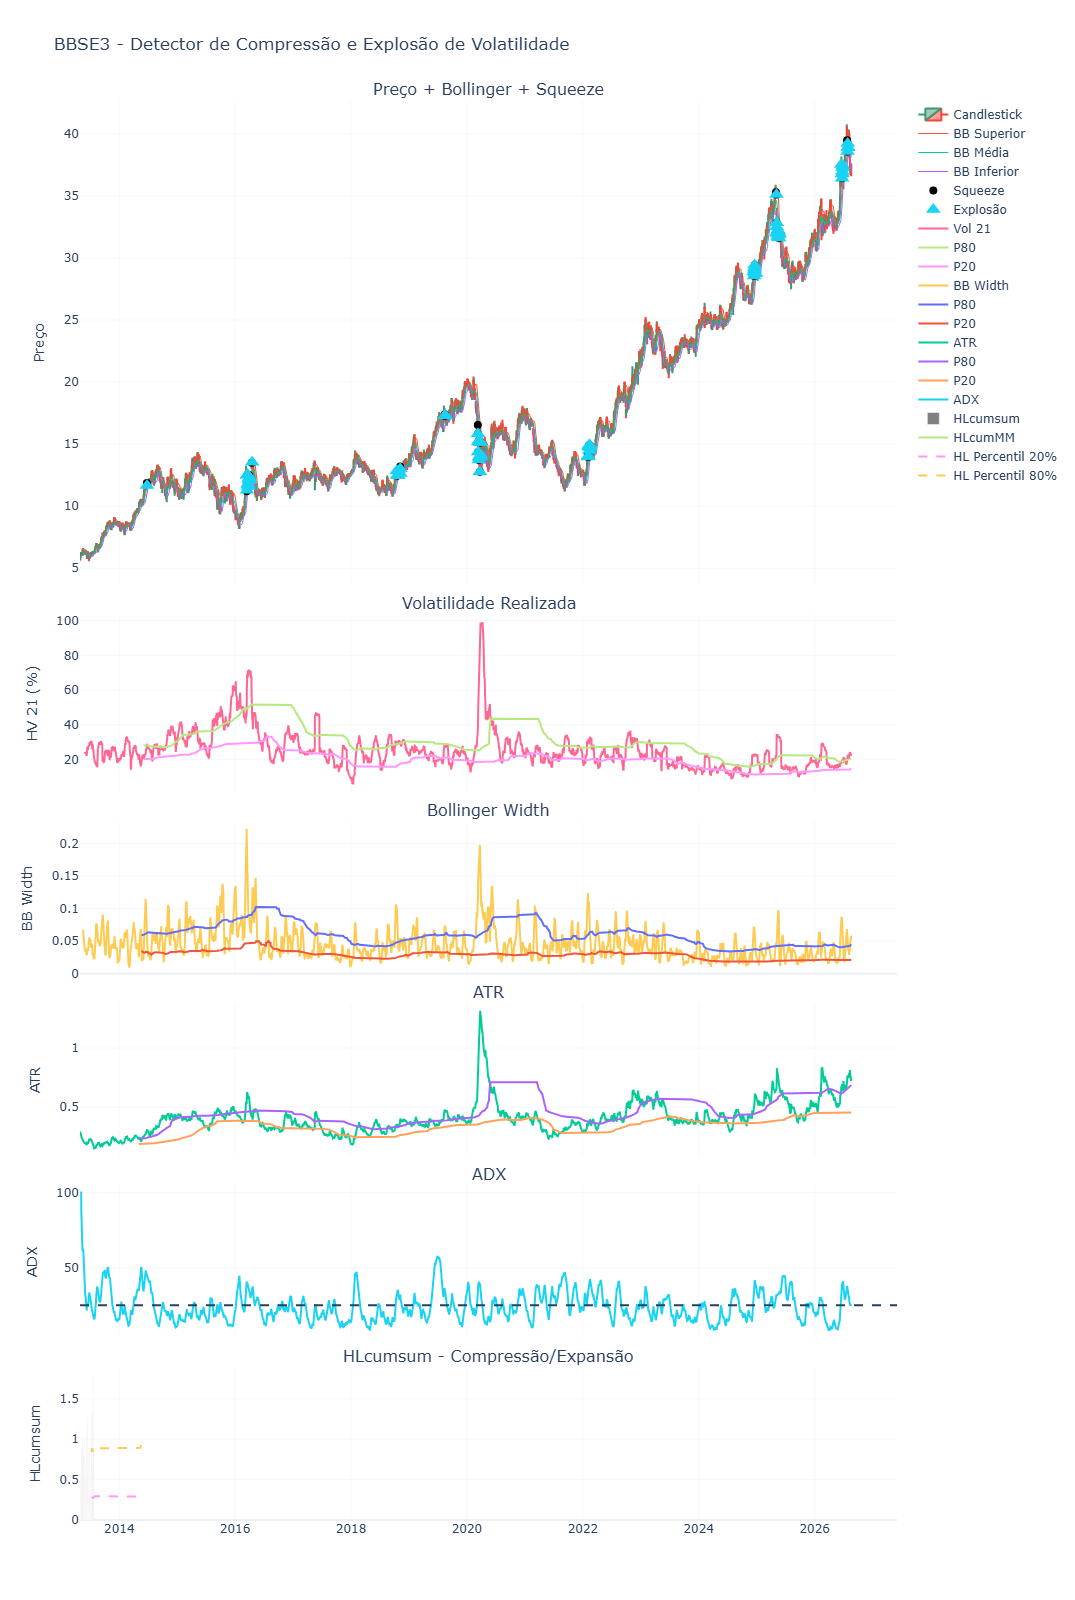

In [67]:
# Importar Todas as Funções
from OPCOES_ExplosaoVol_CLAUDE_GPT_INVERTIDO import *
# coletar ticker =======================================================
from pathlib import Path
import sys

import MetaTrader5 as mt5
import multiprocessing
import os
import time
from concurrent.futures import ThreadPoolExecutor

# Pasta raiz do projeto (um nível acima de Testes)
projeto = Path.cwd().parent

if str(projeto) not in sys.path:
    sys.path.insert(0, str(projeto))


tf = mt5.TIMEFRAME_D1 # TIME FRAME
cotacoes = 3000
NaN_Maximo = 0

tiker = 'BBSE3'

# ==========================================================
# PARÂMETROS QUE DEFINEM AS ENTRADAS (SQUEEZE / EXPLOSÃO)
# Altere os valores abaixo para testar outras configurações.
# ==========================================================
VOL21_PERCENTIL     = 0.80   # percentil mínimo de VOL_21 (0 a 1)
VOL21_JANELA        = 252    # janela (candles) do rolling do percentil
BB_WIDTH_PERCENTIL  = 0.80   # percentil mínimo de BB Width (0 a 1)
BB_WIDTH_JANELA     = 252    # janela (candles) do rolling do percentil
ADX_MINIMO          = 31     # ADX mínimo para squeeze (trend forte)
ATR_CONTRACAO_MULT  = 0.0    # divisor do ATR p/ sinal de explosão (contração)

# COELTAR COM YFINANCE ===================================================
df = carregar_dados(ticker= tiker+".SA", start="2010-01-01", end=None)


# COLETAR COM METATRADER =================================================
#df = cotacoes_mt5_OHLC(tiker, timeframe=tf, n_barras=cotacoes)
# ========================================================================

# Rodar Função ===========================================================
df_squeeze = detectar_contracao(
    df,
    vol21_percentil=VOL21_PERCENTIL,
    vol21_janela=VOL21_JANELA,
    bb_width_percentil=BB_WIDTH_PERCENTIL,
    bb_width_janela=BB_WIDTH_JANELA,
    adx_minimo=ADX_MINIMO,
    atr_contracao_mult=ATR_CONTRACAO_MULT
)
#relatorio(df_squeeze)

# Plotar Gráficos
plotar_interativo(df_squeeze, tiker)

In [69]:
import pandas as pd

pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
pd.set_option("display.max_colwidth", None)

dias_posicionado = 40
bt = backtest_squeeze(
    df_squeeze,
    holding_period = dias_posicionado
)
print(f"Retorno médio........: {bt['Retorno %'].mean():.2f}%")
print(f"Movimento médio......: {bt['Retorno %'].abs().mean():.2f}%")
print(f"Mediana..............: {bt['Retorno %'].median():.2f}%")
print(f"Acerto...............: {(bt['Retorno %'] > 0).mean()*100:.1f}%")

df["Ret_Log"] = np.log(df["Close"] / df["Close"].shift(1))
print(f'Variação Média.......: {(df["Ret_Log"].abs()).mean().round(2)}%')
print(len(bt), 'Numero de Trades')
print(dias_posicionado, 'Dias Posicionado')
print(len(bt[bt['Resultado'] == 'Gain']), 'Numero de Gains')
print(len(bt[bt['Resultado'] == 'Loss']), 'Numero de Loss')
print((len(bt[bt['Resultado'] == 'Gain']) / len(bt[bt['Resultado'] == 'Loss'])))
#display(bt) # Movimento médio......: 5.67%

# Verificar sinal de entrada (Squeeze / Explosão) ======================
sinal = verificar_sinal_entrada(df_squeeze, ticker=tiker)

Retorno médio........: -1.36%
Movimento médio......: 8.12%
Mediana..............: -1.62%
Acerto...............: 39.2%
Variação Média.......: 0.01%
79 Numero de Trades
40 Dias Posicionado
31 Numero de Gains
48 Numero de Loss
0.6458333333333334

SINAL DE ENTRADA - BBSE3
Data do último candle: 2026-08-19 00:00:00
Close.................: 36.66
ADX...................: 24.93
Squeeze (último candle): False
Explosão (último candle): False

>>> SEM SINAL DE ENTRADA no momento <<<

